In [1437]:
import pandas as pd

df =pd.read_parquet("data.parquet")


## Conversion des types

In [1438]:
# domaine_etude => qualitative nominale
# get_dummies drop automatiquement ["domaine_etude"]
# drop_first = Supprime la 1er catégorie (Célibataire) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["domaine_etude"], drop_first=True)

In [1439]:
# statut_marital => qualitative nominale
# get_dummies drop automatiquement ["statut_marital"]
# drop_first = Supprime la 1er catégorie (Célibataire) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["statut_marital"], drop_first=True)


In [1440]:
# departement => qualitative nominale
# get_dummies drop automatiquement ["departement"]
# drop_first = Supprime la 1er catégorie (Commercial) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["departement"], drop_first=True)


In [1441]:
# poste => qualitative nominale
# get_dummies drop automatiquement ["poste"]
# drop_first = Supprime la 1er catégorie (Assistant) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["poste"], drop_first=True)

In [1442]:
pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.values
})

,colonne,type
0,a_quitte_l_entreprise,bool
1,nombre_participation_pee,int64
2,nb_formations_suivies,int64
3,distance_domicile_travail,int64
4,niveau_education,int64
5,frequence_deplacement,int64
6,annees_depuis_la_derniere_promotion,int64
7,annes_sous_responsable_actuel,int64
8,age,int64
9,revenu_mensuel,int64


# corrélation de Pearson

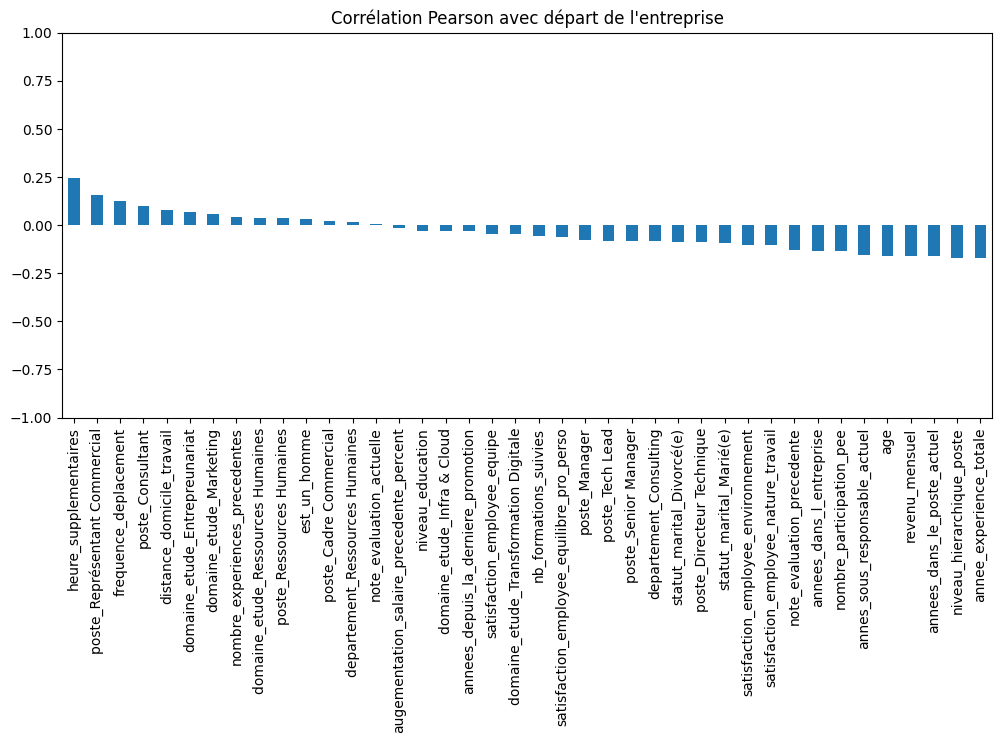

In [1443]:
import matplotlib.pyplot as plt

df["a_quitte_l_entreprise"] = df["a_quitte_l_entreprise"].astype(int)

target_corr = df.corr(numeric_only=True)["a_quitte_l_entreprise"].sort_values(ascending=False)

target_corr.drop("a_quitte_l_entreprise").plot(kind="bar", figsize=(12,5))
plt.title("Corrélation Pearson avec départ de l'entreprise")
plt.ylim(-1, 1)
plt.show()

# séparation train/test

In [1444]:
from sklearn.model_selection import train_test_split

def separation_train_test():
    global X, y, X_train, X_test, y_train, y_test

    X = df.drop(columns=['a_quitte_l_entreprise'])
    y = df['a_quitte_l_entreprise']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    print(f"Taille du jeu d'entraînement : {X_train.shape[0]} lignes")
    print(f"Taille du jeu de test : {X_test.shape[0]} lignes")


# Entrainement

Ici on cherche à prédire le départ ou non d'un salarié, il s'agit d'une classification binaire.

Nous allons tester les modèles suivants en parallèle

* Régression logistique (LogisticRegression)
* Arbres de décision (DecisionTreeClassifier)
* Forêts aléatoires (RandomForestClassifier)
* Gradient Boosting (XGBoost **, LightGBM, CatBoost, GradientBoostingClassifier)


Points importants:
* Nous privilégions le recall pour minimiser les faux-négatifs par rapport aux faux-positifs car nous estimons qu'il est important de ne pas louper un salarié démissionaire

In [1445]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# calcule le taux de distribution pour chaque fold (True/False)
# permet de vérifier si la distribution n'est pas trop déséquilibré (<10%)
def get_split_distribution(cv, X, y):
    dist = []

    for i, (train_idx, test_idx) in enumerate(cv.split(X, y)):

        y_train_fold = y.iloc[train_idx]
        y_test_fold = y.iloc[test_idx]

        dist.append([
            ((y_train_fold == True).sum() / len(y_train_fold)).round(3), # train_pos
            ((y_train_fold == False).sum() / len(y_train_fold)).round(3), # train_neg
            ((y_test_fold == True).sum() / len(y_test_fold)).round(3), # test_pos
            ((y_test_fold == False).sum() / len(y_test_fold)).round(3), # test_neg
        ])

    return dist

def cross_validate(model_name: str, params):

    # choix de l’algorithme (régression, classification, clustering…)
    global X_train, X_test, y_train, y_test


    if model_name == "LogisticRegression":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(**params))
        ])
    elif model_name == "RandomForestClassifier":
        model = RandomForestClassifier(**params)
    elif model_name == "DecisionTreeClassifier":
        model = DecisionTreeClassifier(**params)
    elif model_name == "XGBoost":
        model = XGBClassifier(**params)
    elif model_name == "DummyClassifier":
        model = DummyClassifier(**params)
    else:
        raise ValueError(f"Modèle {model_name} non supporté")

    #
    # validation croisée stratifié
    # pour comparaison des recall's avec le modele entrainé
    #
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="recall"
    )

    # calcule le taux de distribution pour chaque fold (True/False)
    # permet de vérifier si la distribution n'est pas trop déséquilibré (<10% de True)
    dist = get_split_distribution(cv, X_train, y_train)

    return {
            "recall_cross" : scores.round(3),
            "recall_cross_mean" : scores.mean(),
            "recall_cross_dist" : dist
            }


def entrainement_model(model_name: str, params, threshold, pred_test = True):

    # choix de l’algorithme (régression, classification, clustering…)
    global X_train, X_test, y_train, y_test


    if model_name == "LogisticRegression":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(**params))
        ])
    elif model_name == "RandomForestClassifier":
        model = RandomForestClassifier(**params)
    elif model_name == "DecisionTreeClassifier":
        model = DecisionTreeClassifier(**params)
    elif model_name == "XGBoost":
        model = XGBClassifier(**params)
    elif model_name == "DummyClassifier":
        model = DummyClassifier(**params)
    else:
        raise ValueError(f"Modèle {model_name} non supporté")

    #
    # Entraînement
    #
    model.fit(X_train, y_train)

    if pred_test == True:

        # Prédictions
        y_pred = model.predict(X_test)
        
        # obtient la probabilité d’appartenance à chaque classe des prédictions (pour mesurer les scores et ajuster les prédictions)
        y_proba = model.predict_proba(X_test)[:, 1]

        # ajuste les prédictions en fonction du seuil de probabilité
        y_pred = (y_proba >= threshold)

        # évaluation des performances (accuracy, RMSE, F1, etc.)
        return {
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "r2": r2_score(y_test, y_pred),
            "auc" : roc_auc_score(y_test, y_proba),
            "y_proba" : y_proba,
            "y_pred" : y_pred,
            "X" : X_test,
            "y" : y_test,
            "clf" : model
        }

    # Prédictions
    y_pred_train = model.predict(X_train)
    
    # obtient la probabilité d’appartenance à chaque classe des prédictions (pour mesurer les scores et ajuster les prédictions)
    y_proba_train = model.predict_proba(X_train)[:, 1]

    # ajuste les prédictions en fonction du seuil de probabilité
    y_pred_train = (y_proba_train >= threshold)

    # évaluation des performances (accuracy, RMSE, F1, etc.)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_train, y_pred_train),
        "precision": precision_score(y_train, y_pred_train),
        "recall": recall_score(y_train, y_pred_train),
        "f1": f1_score(y_train, y_pred_train),
        "r2": r2_score(y_train, y_pred_train),
        "auc" : roc_auc_score(y_train, y_proba_train),
        "y_proba" : y_proba_train,
        "y_pred" : y_pred_train,
        "X" : X_train,
        "y" : y_train,
        "clf" : model
    }


# Résultat

In [1446]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve
import pandas as pd

def print_split_distribution(*args) -> None:

    print("Validation croisée stratifié 'recall'")
    print("   Il est important de vérifier que la distribution des folds 'strates' dans le jeu d'entrainement n'est pas trop déséquilibré.")

    print()

    with pd.option_context(
        'display.max_rows', None,
        'display.max_columns', None,
        'display.max_colwidth', None,
        'display.width', None
    ):
        with pd.option_context('display.float_format', '{:.3f}'.format):
            for results_list in args:
                for r in results_list:
                    print(r["model"])
                    results = pd.DataFrame(results_list, columns=["recall", "recall_cross_mean", "recall_cross"])
                    display(results.T)
                    display(pd.DataFrame(r["recall_cross_dist"]))

def print_results(*args) -> None:
    print("R²")
    print("   1.0   = (bon modèle)           prédictions exactes ")
    print("   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple ")
    print("   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne ")

    print()

    print("precision / recall")
    print("   Precision = fiabilité des alertes")
    print("               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)")
    print("   Recall    = capacité à détecter les vrais cas")
    print("               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués")
    print("   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)")
    print("   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs")

    print()

    print("Validation croisée stratifié 'recall'")
    print("   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.")
    print("   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.")

    print()

    print("AUC")
    print("   Exemple : recall_cross_mean = 0.95, le modèle a un rappel moyen de 95% (capacité à détecter les vrais cas) sur les différentes stratification du jeu de test.")

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)

    with pd.option_context(
        'display.max_rows', None,
        'display.max_columns', None,
        'display.max_colwidth', None,
        'display.width', None
    ):
        with pd.option_context('display.float_format', '{:.3f}'.format):
            for results_list in args:
                results = pd.DataFrame(results_list, columns=["model", "accuracy", "precision", "recall", "f1", "r2"])
                display(results)


def display_results(*args) -> None:
    for results_list in args:
        i = 0
        fig, axes = plt.subplots(3, len(results_list), figsize=(15, 8))

        for results in results_list:
            ax = axes[0,i]
            sns.histplot(
                results["y_proba"],
                ax=axes[0,i])
            
            ConfusionMatrixDisplay.from_predictions(
                results["y"],
                results["y_pred"],
                ax=axes[1,i]
            )

            fpr, tpr, thresholds = roc_curve(results["y"], results["clf"].predict_proba(results["X"])[:,1])
            plt.axes(axes[2,i])
            plt.plot(fpr, tpr)
            plt.grid()
            plt.title("ROC curve")
            
            ax.set_title(results["model"])
            i = i+1

        plt.tight_layout()
        plt.show()


# entraînement du modèle

In [1447]:
from IPython.display import display, Markdown

class BaseTrain:
    pass_list = []
    pass_names = []
    pass_num = 0 # numero de passe d'entrainement (pour affichage)

    # Par défaut nous partons sur le seuil d'ajustement des classes par défaut: 0.5
    threshold = 0.5

    #
    # paramètres de chaque modèle
    #

    # un modèle linéaire
    LogisticRegressionParams = {
        
    }

    # un modèle dummy
    DummyClassifierParams = {
        "strategy":"stratified"
    }

    # un modèle non-linéaire
    XGBoostParams = {
        "n_estimators": 200,
        "max_depth": 4,
        "eval_metric": "logloss"
    }

    #
    # autres paramètres de modèles (pour test)
    #

    RandomForestClassifierParams = {
        "n_estimators": 200,
        "random_state": 42
    }

    DecisionTreeClassifierParams = {
        "max_depth": 4,
        "random_state": 42
    }

    def __init__(self, desc):
        self.name = self.__class__.__name__
        self.desc = desc
        BaseTrain.pass_names.append(self.name)
        
    def before(self):
        return None

    def after(self):
        return None

    def train_and_evaluate(self):
        
        self.before()

        self.results_list = []
        self.results_list.append(entrainement_model("DummyClassifier", BaseTrain.DummyClassifierParams, BaseTrain.threshold, True))
        self.results_list.append(entrainement_model("LogisticRegression", BaseTrain.LogisticRegressionParams, BaseTrain.threshold, True))
        self.results_list.append(entrainement_model("XGBoost", BaseTrain.XGBoostParams, BaseTrain.threshold, True))
        BaseTrain.pass_list.append(self.results_list)

        self.train_results_list = []
        self.train_results_list.append(entrainement_model("DummyClassifier", BaseTrain.DummyClassifierParams, BaseTrain.threshold, False))
        self.train_results_list.append(entrainement_model("LogisticRegression", BaseTrain.LogisticRegressionParams, BaseTrain.threshold, False))
        self.train_results_list.append(entrainement_model("XGBoost", BaseTrain.XGBoostParams, BaseTrain.threshold, False))

        BaseTrain.pass_num = BaseTrain.pass_num+1
        
        self.after()
        
    def print(self):
        display(Markdown(f"""# PASSE N°{BaseTrain.pass_num}\n## {self.name}\n\n**{self.desc}**"""))

        print_results(self.results_list, self.train_results_list)
        display_results(self.results_list, self.train_results_list)

In [1448]:
# séparation train/test

separation_train_test()


Taille du jeu d'entraînement : 1176 lignes
Taille du jeu de test : 294 lignes


# PASSE N°1
## InitialTrain

**Premier entrainement**

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

Validation croisée stratifié 'recall'
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.
   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.

AUC
   Exemple : recall_cross_mean = 0.95, le modèle a un rappe

,model,accuracy,precision,recall,f1,r2
0,DummyClassifier,0.711,0.103,0.154,0.124,-1.513
1,LogisticRegression,0.881,0.577,0.385,0.462,-0.035
2,XGBoost,0.874,0.545,0.308,0.393,-0.094


,model,accuracy,precision,recall,f1,r2
0,DummyClassifier,0.709,0.160,0.172,0.166,-1.077
1,LogisticRegression,0.888,0.762,0.485,0.593,0.198
2,XGBoost,1.000,1.000,1.000,1.000,1.000


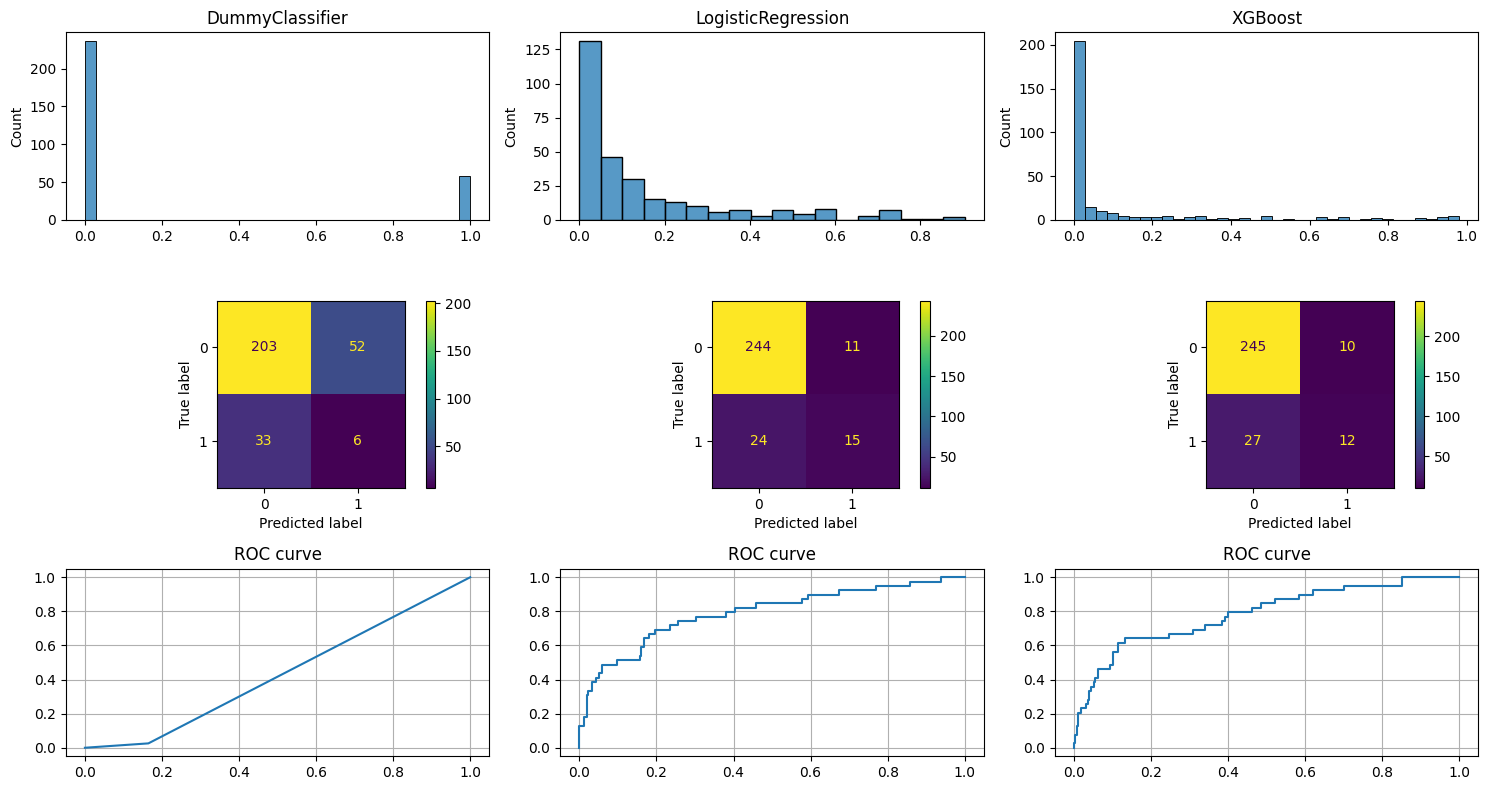

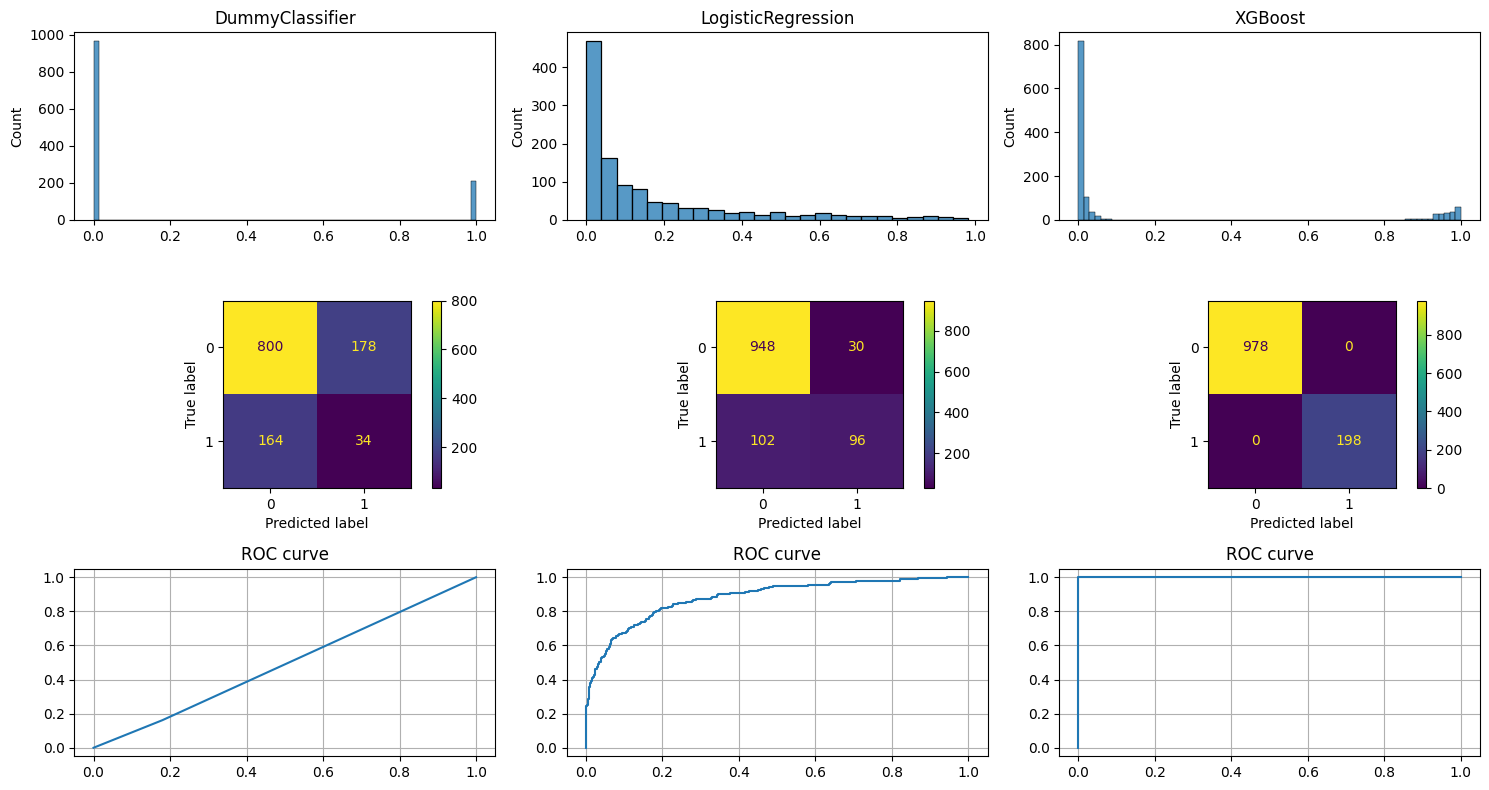

In [1449]:
class InitialTrain(BaseTrain):
    def before(self):
        return None

    def after(self):
        return None

passInst = InitialTrain("Premier entrainement")
passInst.train_and_evaluate()
passInst.print()

## validation croisée

Validation croisée stratifié 'recall'
   Il est important de vérifier que la distribution des folds 'strates' dans le jeu d'entrainement n'est pas trop déséquilibré.
   Si < 10% de positifs le jeu est mal proportionné
   
StratifiedKFold équilibre les proportions de True/False, si OK, le jeu est bien distribué.

Si non, vérifier:
* modèle XGBoost
* seuil de décision
* qualité des variables explicatives
* surapprentissage ?

In [1450]:
results = cross_validate("XGBoost", BaseTrain.XGBoostParams)

result = next((x for x in passInst.results_list if x["model"] == "XGBoost"), None)

print("recall score actuel:", result["recall"])
print_split_distribution([results | result])

recall score actuel: 0.3076923076923077
Validation croisée stratifié 'recall'
   Il est important de vérifier que la distribution des folds 'strates' dans le jeu d'entrainement n'est pas trop déséquilibré.

XGBoost


,0
recall,0.308
recall_cross_mean,0.389
recall_cross,"[0.275, 0.385, 0.41, 0.475, 0.4]"


,0,1,2,3
0,0.168,0.832,0.169,0.831
1,0.169,0.831,0.166,0.834
2,0.169,0.831,0.166,0.834
3,0.168,0.832,0.170,0.830
4,0.168,0.832,0.170,0.830


classe positive (True) : ~17 %
classe négative (False) : ~83 %

Distribution plutot saine:
* pas de fold sans positifs
* pas de déséquilibre extrême
* stratification globalement correcte

Taille du jeu d'entraînement : 1176 lignes
Taille du jeu de test : 294 lignes


# PASSE N°2
## FeaturesPass

**Supprime les features trop corrélés**

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

Validation croisée stratifié 'recall'
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.
   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.

AUC
   Exemple : recall_cross_mean = 0.95, le modèle a un rappe

,model,accuracy,precision,recall,f1,r2
0,DummyClassifier,0.735,0.118,0.154,0.133,-1.306
1,LogisticRegression,0.884,0.593,0.410,0.485,-0.005
2,XGBoost,0.871,0.522,0.308,0.387,-0.123


,model,accuracy,precision,recall,f1,r2
0,DummyClassifier,0.697,0.124,0.131,0.127,-1.162
1,LogisticRegression,0.886,0.754,0.480,0.586,0.186
2,XGBoost,1.000,1.000,1.000,1.000,1.000


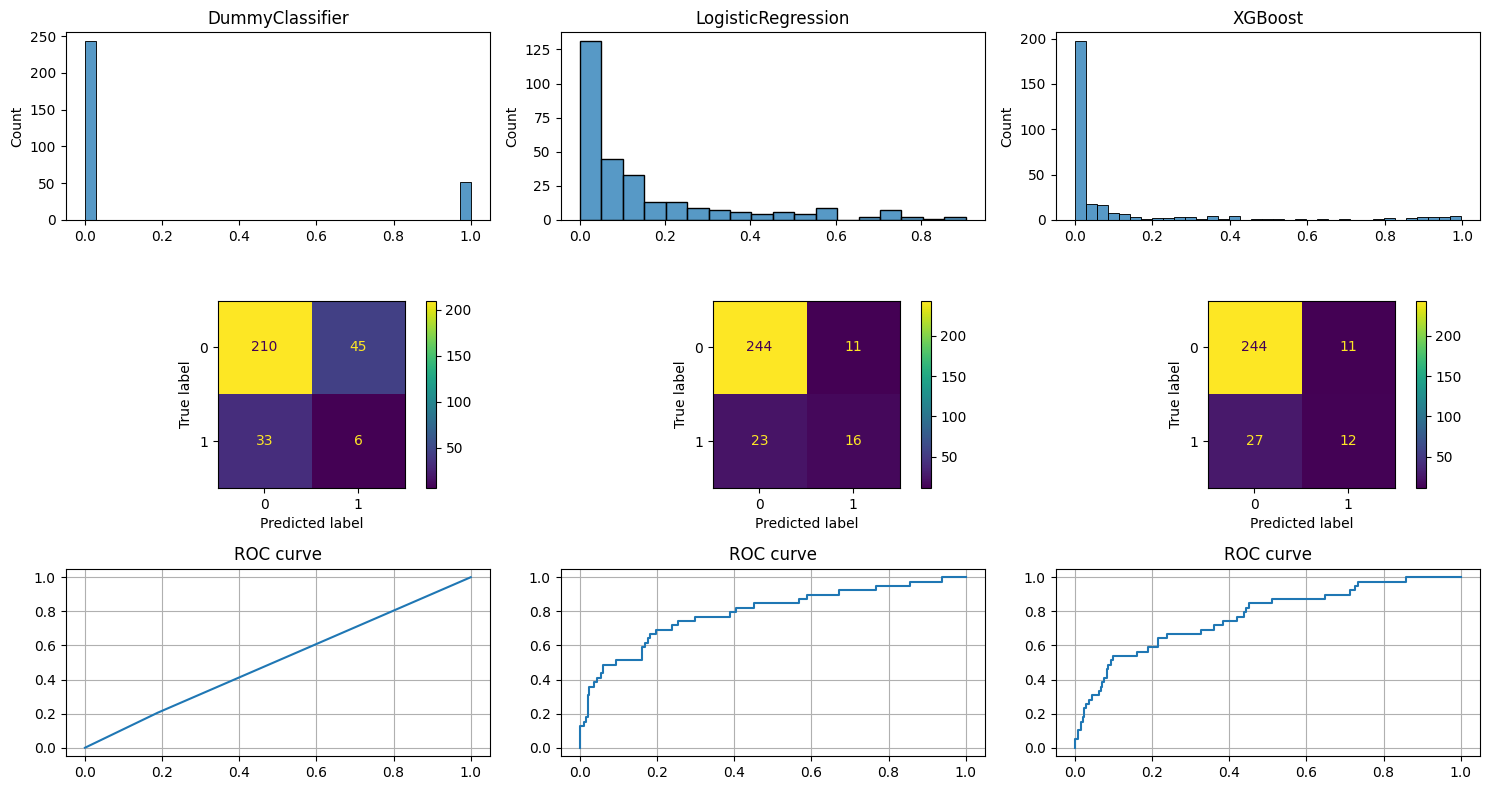

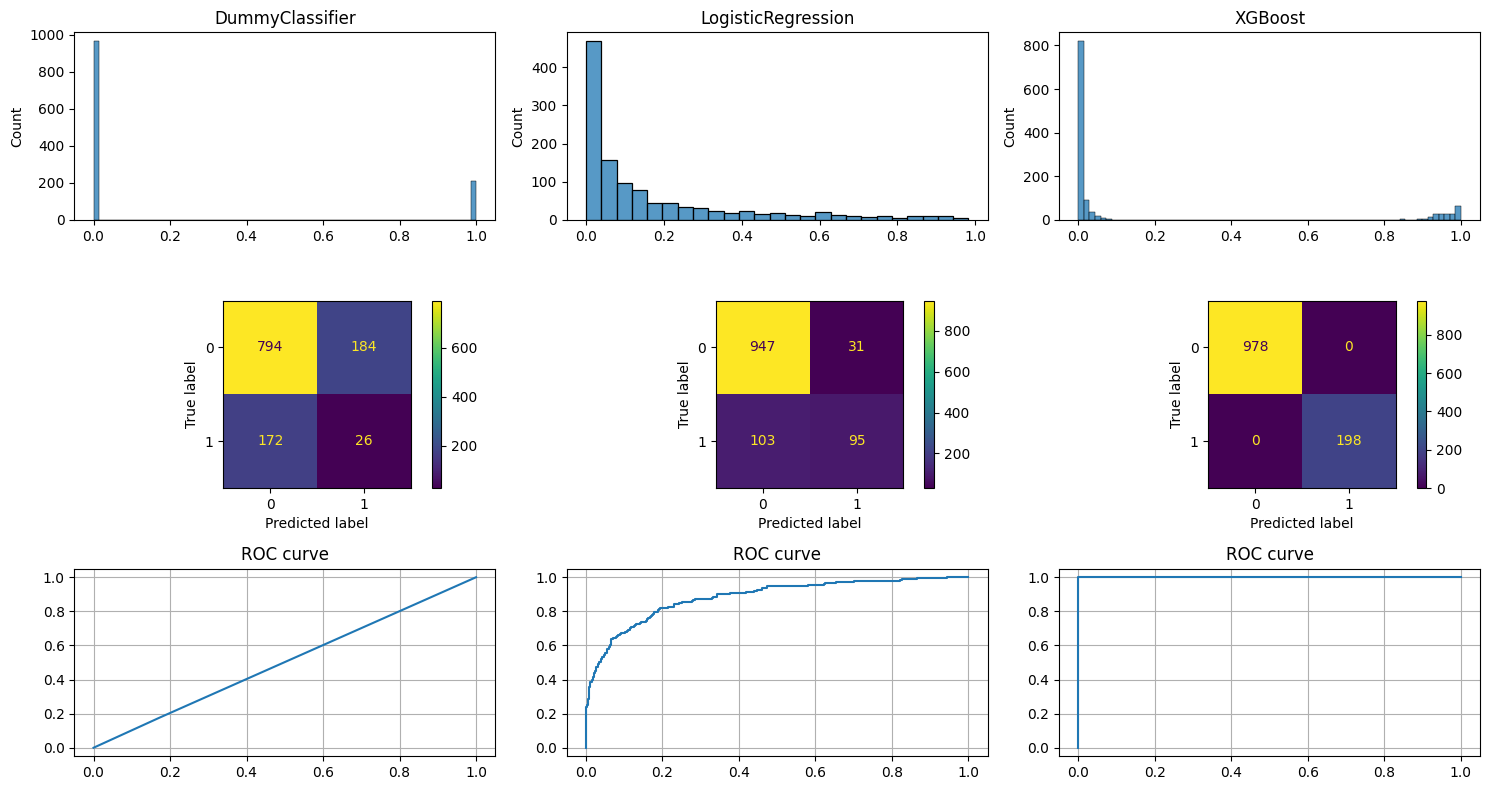

In [1451]:
class FeaturesPass(BaseTrain):
    def before(self):
        # on essaie de supprimer la feature "niveau_hierarchique_poste" (fortement corrélé à "revenu_mensuel")
        df.drop(columns=["niveau_hierarchique_poste"], inplace=True)

        # on recréer le jeu de données
        separation_train_test()

passInst = FeaturesPass("Supprime les features trop corrélés")
passInst.train_and_evaluate()
passInst.print()

# Overfit

* Le modèle XGBoost présente un fort Sur-apprentissage sur le jeu d'entrainement F1-score 0.98 / 0.42
* Le modèle LogisticRegression est moins affecté par le Sur-apprentissage 0.48 / 0.58
* Les modèles restent meilleur que le dummy de référence


Remédiations:
* Vérifier la qualité du découpage entraînement / test => contrôler les doublons d’ID ou les chevauchements de groupes entre train et test ou split par groupe plutôt qu’un split aléatoire
* Vérifier la présence de fuite de données dans les variables explicatives => revue des features et de leur mode de calcul est souvent nécessaire, en particulier pour les agrégations
* Une complexité excessive du modèle par rapport à la quantité de données => la régularisation, la réduction de profondeur, le subsampling des lignes et des colonnes permettent de forcer une généralisation plus robuste

# Vérifie la répartition des données train/test

In [1452]:
df["a_quitte_l_entreprise"].value_counts(normalize=True)

a_quitte_l_entreprise
0    0.838776
1    0.161224
Name: proportion, dtype: float64

In [1453]:
y_train.value_counts(normalize=True)

a_quitte_l_entreprise
0    0.831633
1    0.168367
Name: proportion, dtype: float64

In [1454]:
y_test.value_counts(normalize=True)

a_quitte_l_entreprise
0    0.867347
1    0.132653
Name: proportion, dtype: float64

La répartition true / false est plutot bien répartie



Dans ce type de situation (ex : démissions rares), XGBoost peut privilégier fortement la classe majoritaire.

Résultat :

prédictions quasi toujours négatives
donc faux négatifs élevés
rappel très faible voire nul sur certains folds

# amélioration du modèle

237 1233 5.2025316455696204


# PASSE N°3
## ParamsPass

**Ajuste les paramètres de poids**

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

Validation croisée stratifié 'recall'
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.
   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.

AUC
   Exemple : recall_cross_mean = 0.95, le modèle a un rappe

,model,accuracy,precision,recall,f1,r2
0,DummyClassifier,0.707,0.088,0.128,0.104,-1.542
1,LogisticRegression,0.884,0.593,0.410,0.485,-0.005
2,XGBoost,0.867,0.500,0.385,0.435,-0.153


,model,accuracy,precision,recall,f1,r2
0,DummyClassifier,0.693,0.102,0.106,0.104,-1.192
1,LogisticRegression,0.886,0.754,0.480,0.586,0.186
2,XGBoost,1.000,1.000,1.000,1.000,1.000


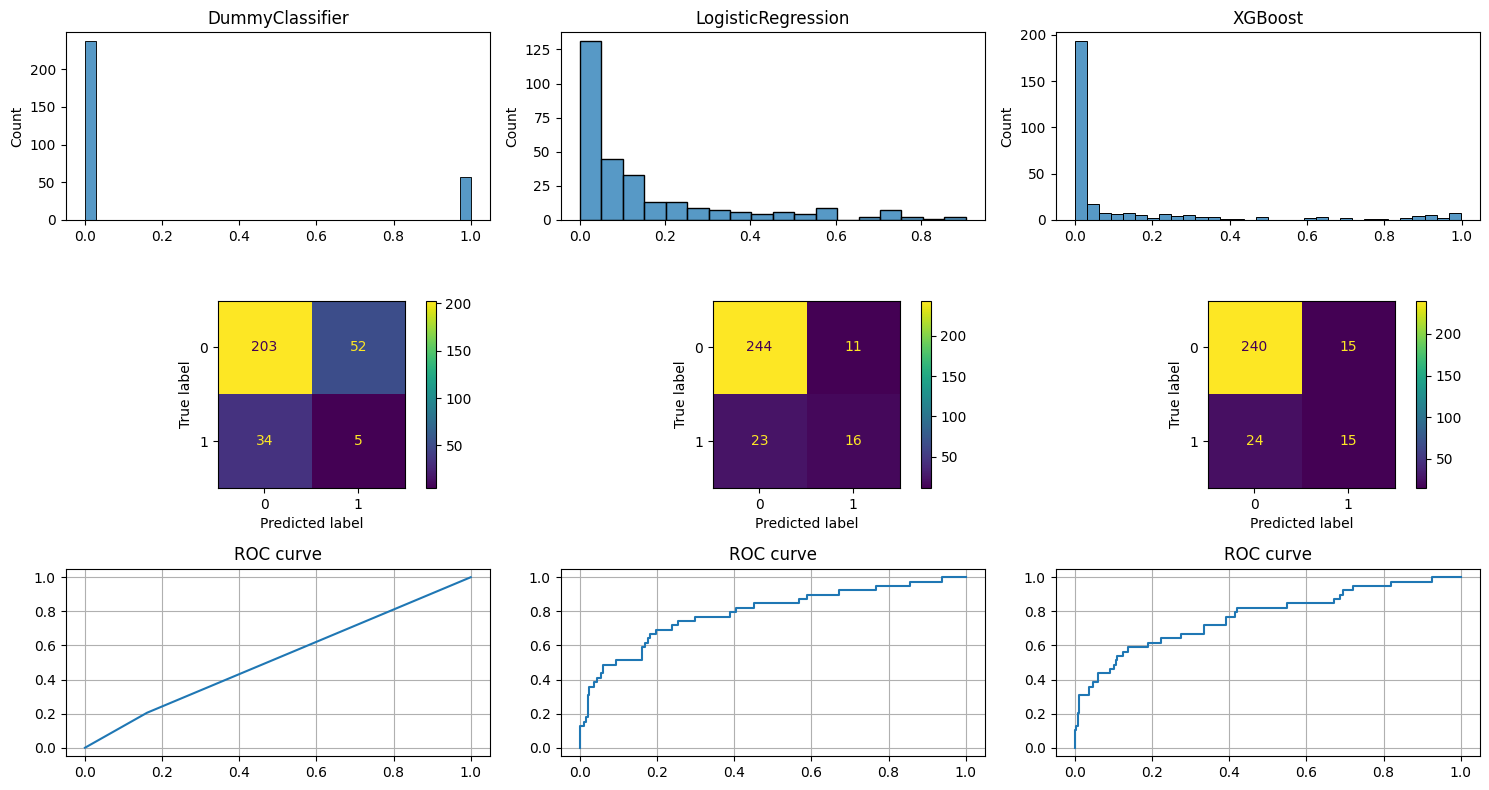

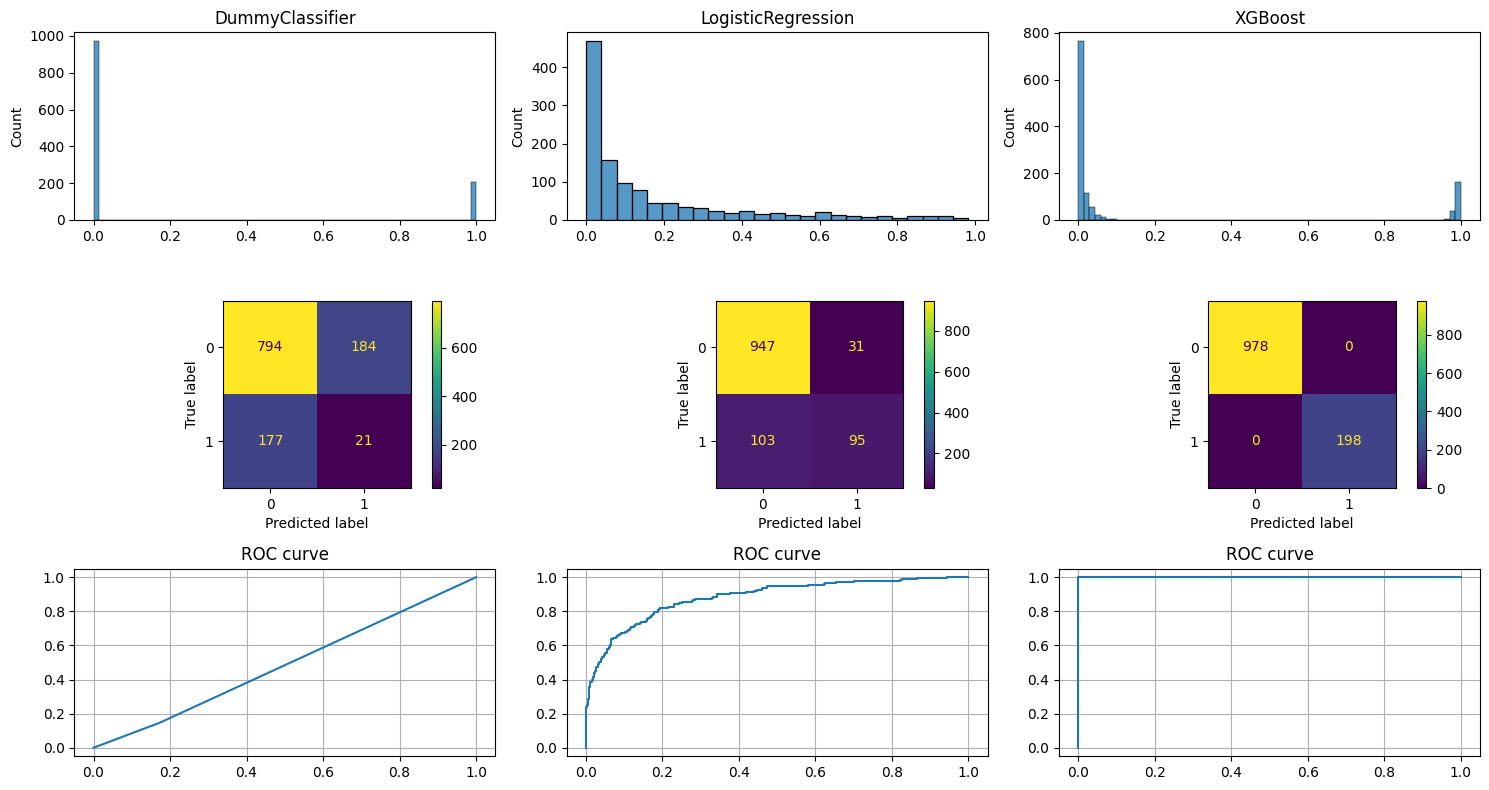

In [1455]:
class ParamsPass(BaseTrain):
    def before(self):
        # on essaie de supprimer la feature "niveau_hierarchique_poste" (fortement corrélé à "revenu_mensuel")
        BaseTrain.RandomForestClassifierParams["class_weight"] = "balanced"

        # equilibre le poids 
        nb_pos = (df["a_quitte_l_entreprise"] == True).sum()
        nb_neg = (df["a_quitte_l_entreprise"] == False).sum()
        BaseTrain.XGBoostParams["scale_pos_weight"] = nb_neg / nb_pos
        print(nb_pos, nb_neg, BaseTrain.XGBoostParams["scale_pos_weight"])

passInst = ParamsPass("Ajuste les paramètres de poids")
passInst.train_and_evaluate()
passInst.print()

In [1456]:
class GroupFeaturesPass(BaseTrain):
    def before(self):
        df["pression_travail"] = df["heure_supplementaires"] * df["frequence_deplacement"]

        df["insatisfaction_globale"] = (
            df["satisfaction_employee_nature_travail"] +
            df["satisfaction_employee_equipe"] +
            df["satisfaction_employee_equilibre_pro_perso"]
        )

        df.drop(columns=["satisfaction_employee_nature_travail"], inplace=True)
        df.drop(columns=["satisfaction_employee_equipe"], inplace=True)
        df.drop(columns=["satisfaction_employee_equilibre_pro_perso"], inplace=True)
        df.drop(columns=["heure_supplementaires"], inplace=True)
        df.drop(columns=["frequence_deplacement"], inplace=True)

        # séparation train/test
        separation_train_test()

#passInst = GroupFeaturesPass("Réduit le nombre de features")
#passInst.train_and_evaluate()
#passInst.print()

# recherche du meilleur seuil (XGBoost)

Best threshold: 0.4
Best F1: 0.4657534246575342


# PASSE N°4
## ThresholdPass

**Ajuste le seuil de choix de classe en fonction du meilleur F1-score**

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

Validation croisée stratifié 'recall'
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.
   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.

AUC
   Exemple : recall_cross_mean = 0.95, le modèle a un rappe

,model,accuracy,precision,recall,f1,r2
0,DummyClassifier,0.772,0.150,0.154,0.152,-0.981
1,LogisticRegression,0.871,0.514,0.487,0.500,-0.123
2,XGBoost,0.867,0.500,0.436,0.466,-0.153


,model,accuracy,precision,recall,f1,r2
0,DummyClassifier,0.719,0.196,0.217,0.206,-1.010
1,LogisticRegression,0.879,0.661,0.581,0.618,0.138
2,XGBoost,1.000,1.000,1.000,1.000,1.000


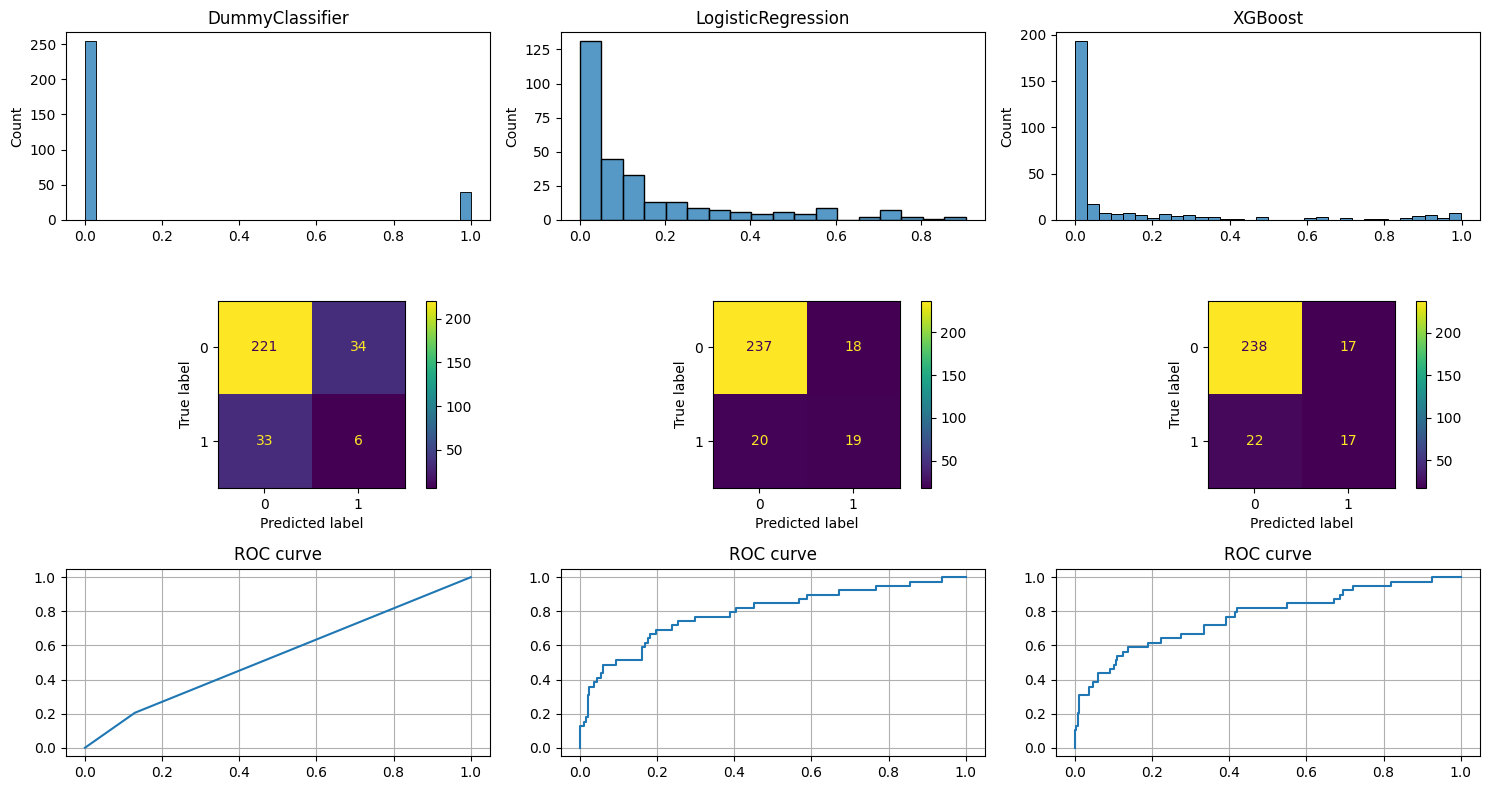

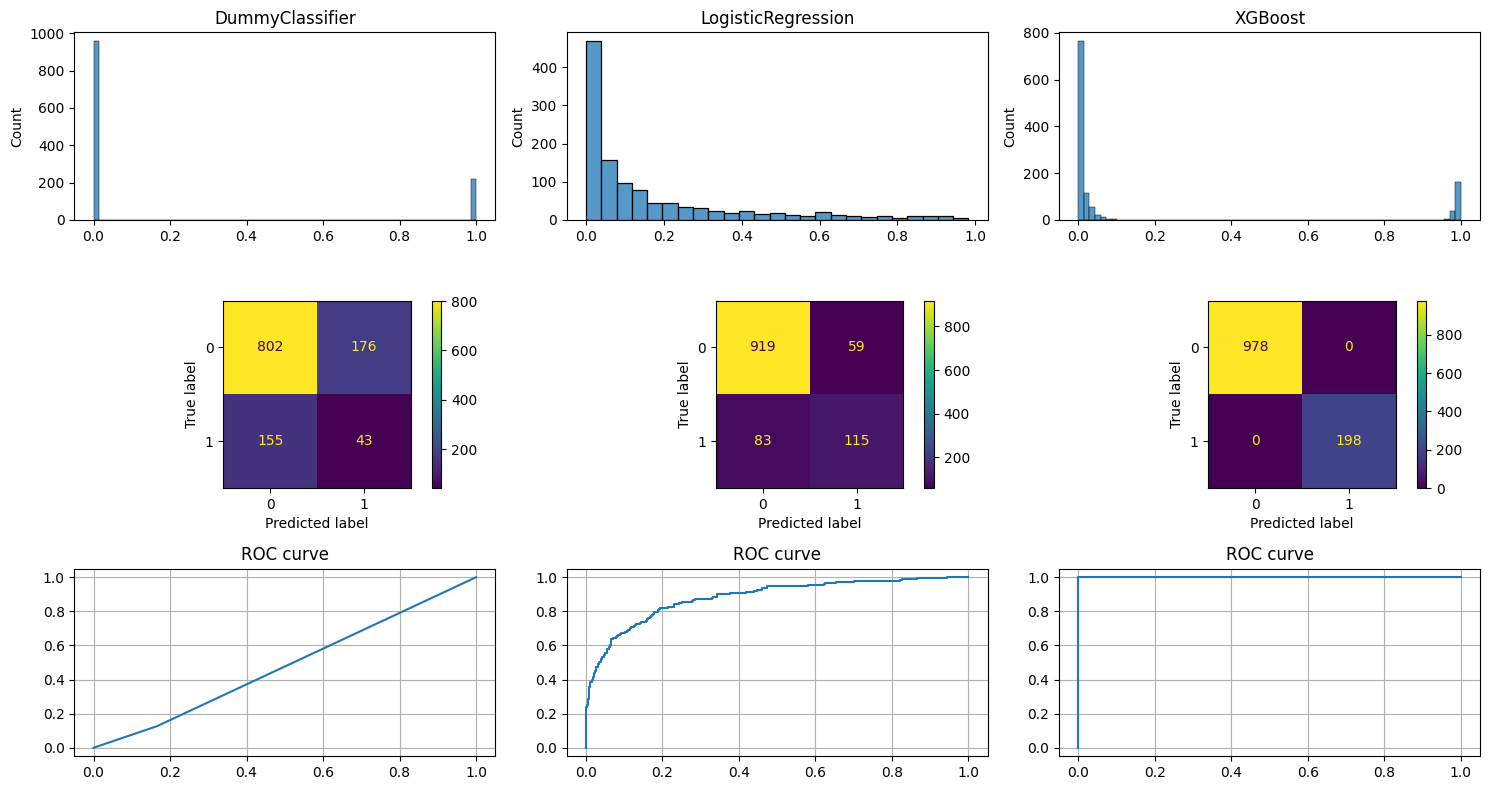

In [1457]:
class ThresholdPass(BaseTrain):
    MODE = "f1"

    def before(self):
        best_t, best_f1, best_recall = 0, 0, 0

        for t in range(1, 9, 1):
            threshold = 0.1 * t
            results = entrainement_model("XGBoost", BaseTrain.XGBoostParams, threshold, True)

            if ThresholdPass.MODE == "f1":
                f1 = results["f1"]
                    
                if f1 > best_f1:
                    best_f1 = f1
                    best_t = threshold

            if ThresholdPass.MODE == "recall":
                recall = results["recall"]

                if recall > best_recall:
                    best_recall = recall
                    best_t = threshold

        print("Best threshold:", best_t)

        if ThresholdPass.MODE == "f1":
            print("Best F1:", best_f1)

        if ThresholdPass.MODE == "recall":
            print("Best Recall:", best_recall)

        BaseTrain.threshold = best_t
        

passInst = ThresholdPass("Ajuste le seuil de choix de classe en fonction du meilleur F1-score")
passInst.train_and_evaluate()
passInst.print()

# optimisation des hyperparamètres

# Affiche un graphique de l'évolution du F1-score

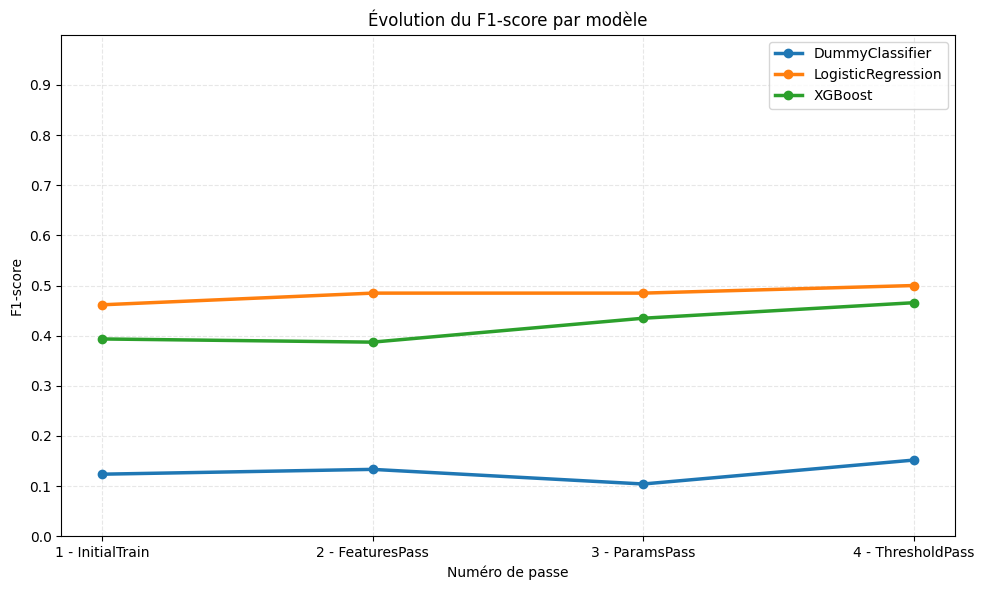

In [1458]:
import matplotlib.pyplot as plt
import numpy as np

# noms des modèles (pris sur la première passe)
models = [r["model"] for r in BaseTrain.pass_list[0]]

# construction matrice : lignes = passes, colonnes = modèles
data = np.empty((len(BaseTrain.pass_list), len(models)))

j = 0
for results_list in BaseTrain.pass_list:
    i = 0
    for results in results_list:
        data[j, i] = results["f1"]
        i += 1
    j += 1


# PLOT
fig, ax = plt.subplots(figsize=(10, 6))

x = range(1, len(BaseTrain.pass_list)+1, 1)  # numéro de passe

i = 0
for model in models:

    f1_scores = data[:, i]

    ax.plot(
        x,
        f1_scores,
        marker='o',
        linewidth=2.5,
        label=model
    )

    i += 1

ax.set_ylim(0, 1)
ax.set_title("Évolution du F1-score par modèle")
ax.set_xlabel("Numéro de passe")
ax.set_ylabel("F1-score")
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()


labels_avec_numero = [f"{i+1} - {label}" for i, label in enumerate(BaseTrain.pass_names)]
plt.xticks(x, labels_avec_numero)
plt.yticks(np.arange(0, 1, 0.1))
plt.tight_layout()
plt.show()

In [1459]:
pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.values
})

,colonne,type
0,a_quitte_l_entreprise,int64
1,nombre_participation_pee,int64
2,nb_formations_suivies,int64
3,distance_domicile_travail,int64
4,niveau_education,int64
5,frequence_deplacement,int64
6,annees_depuis_la_derniere_promotion,int64
7,annes_sous_responsable_actuel,int64
8,age,int64
9,revenu_mensuel,int64


# Prédictions sur de nouvelles données

# Export

In [1460]:
df.to_parquet("model.parquet")